<a href="https://colab.research.google.com/github/Dripp234/day3AI/blob/main/ASSIGNMENT_DAY_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import zipfile
import os
import cv2

zip_path = "/content/archive (1).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 484


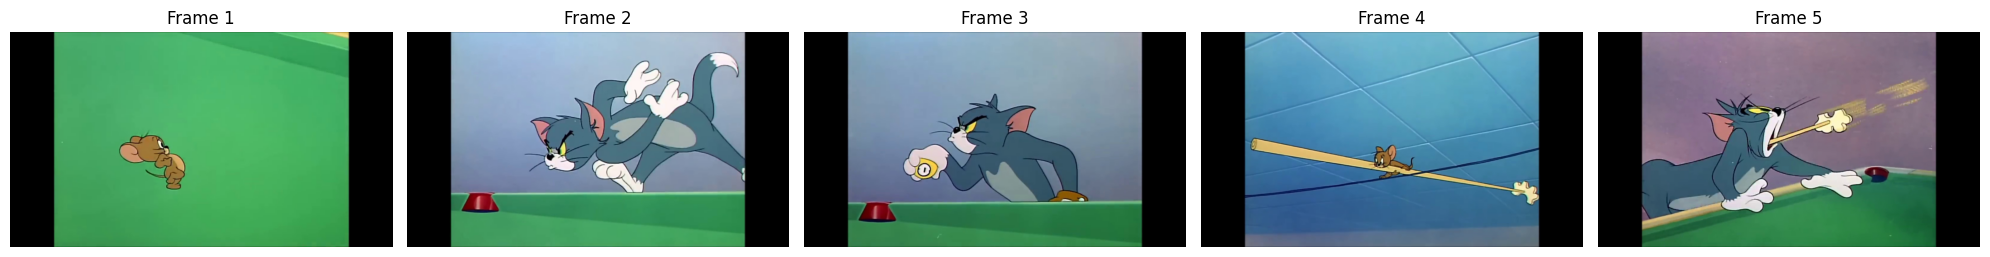

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Define image paths
img_pth1 = "/content/extracted_images/test/test_extract/frame130.jpg"
img_pth2 = "/content/extracted_images/test/test_extract/frame1.jpg"
img_pth3 = "/content/extracted_images/test/test_extract/frame22.jpg"
img_pth4 = "/content/extracted_images/test/test_extract/frame105.jpg"
img_pth5 = "/content/extracted_images/test/test_extract/frame120.jpg"

# 2. Load images using PIL
images = [
    Image.open(img_pth1),
    Image.open(img_pth2),
    Image.open(img_pth3),
    Image.open(img_pth4),
    Image.open(img_pth5),
]

# 3. Setup the matplotlib figure (1 row, 5 columns)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# 4. Loop through and display each image
for i, img in enumerate(images):
    axes[i].imshow(img)
    axes[i].set_title(f"Frame {i+1}")
    axes[i].axis("off")  # Hides the pixel coordinate axes for a cleaner look

# 5. Display the plot
plt.tight_layout()
plt.show()

In [9]:
from PIL import Image
import pandas as pd

# Define image paths
img_paths = {
    "frame113": "/content/extracted_images/test/test_extract/frame130.jpg",
    "frame1": "/content/extracted_images/test/test_extract/frame1.jpg",
    "frame10": "/content/extracted_images/test/test_extract/frame22.jpg",
    "frame105": "/content/extracted_images/test/test_extract/frame105.jpg",
    "frame120": "/content/extracted_images/test/test_extract/frame120.jpg",
}

# List to hold metadata dictionaries
image_metadata = []

for name, path in img_paths.items():
    try:
        # Open image
        img = Image.open(path)

        # Extract dimensions (width, height)
        width, height = img.size

        # Get number of channels (e.g., 3 for RGB, 4 for RGBA, 1 for L/Grayscale)
        channels = len(img.getbands())

        # Append details to the list
        image_metadata.append(
            {
                "Image Name": name,
                "Width": width,
                "Height": height,
                "Channels": channels,
                "Path": path,
            }
        )
    except FileNotFoundError:
        print(f"Warning: File not found at {path}")

# Create a DataFrame table
df = pd.DataFrame(image_metadata)

# Display the table
print(df)

# Optional: Save the table to a CSV file
# df.to_csv("image_dimensions.csv", index=False)

  Image Name  Width  Height  Channels  \
0   frame113   1280     720         3   
1     frame1   1280     720         3   
2    frame10   1280     720         3   
3   frame105   1280     720         3   
4   frame120   1280     720         3   

                                                Path  
0  /content/extracted_images/test/test_extract/fr...  
1  /content/extracted_images/test/test_extract/fr...  
2  /content/extracted_images/test/test_extract/fr...  
3  /content/extracted_images/test/test_extract/fr...  
4  /content/extracted_images/test/test_extract/fr...  


In [10]:
from PIL import Image

# 1. Define your paths (as previously set up)
img_paths = [
    "/content/extracted_images/test/test_extract/frame113.jpg",
    "/content/extracted_images/test/test_extract/frame1.jpg",
    "/content/extracted_images/test/test_extract/frame10.jpg",
    "/content/extracted_images/test/test_extract/frame105.jpg",
    "/content/extracted_images/test/test_extract/frame120.jpg",
]

# Target dimensions
target_size = (224, 224)

# 2. Load and resize the images using a list comprehension
# Image.Resampling.LANCZOS ensures high-quality downscaling
resized_images = [
    Image.open(path).resize(target_size, Image.Resampling.LANCZOS)
    for path in img_paths
]

# 3. Assign them back to your distinct variables if needed
image, image2, image3, image4, image5 = resized_images

print("All images have been successfully resized to 224x224!")

# --- OPTIONAL: Save the resized images to disk ---
# If you want to permanently save them (e.g., appending '_resized' to the filename):
# for path, img in zip(img_paths, resized_images):
#     new_path = path.replace(".jpg", "_224x224.jpg")
#     img.save(new_path)
#     print(f"Saved: {new_path}")

All images have been successfully resized to 224x224!


In [11]:
# 1. Convert all images to Grayscale ('L' mode)
grayscale_images = [
    image.convert("L"),
    image2.convert("L"),
    image3.convert("L"),
    image4.convert("L"),
    image5.convert("L"),
]

# 2. Convert all images to RGB (Standard Color mode)
rgb_images = [
    image.convert("RGB"),
    image2.convert("RGB"),
    image3.convert("RGB"),
    image4.convert("RGB"),
    image5.convert("RGB"),
]

# 3. Convert all images to HSV
# PIL handles HSV via 'HSV' mode
hsv_images = [
    image.convert("HSV"),
    image2.convert("HSV"),
    image3.convert("HSV"),
    image4.convert("HSV"),
    image5.convert("HSV"),
]

print("Conversion complete!")

Conversion complete!


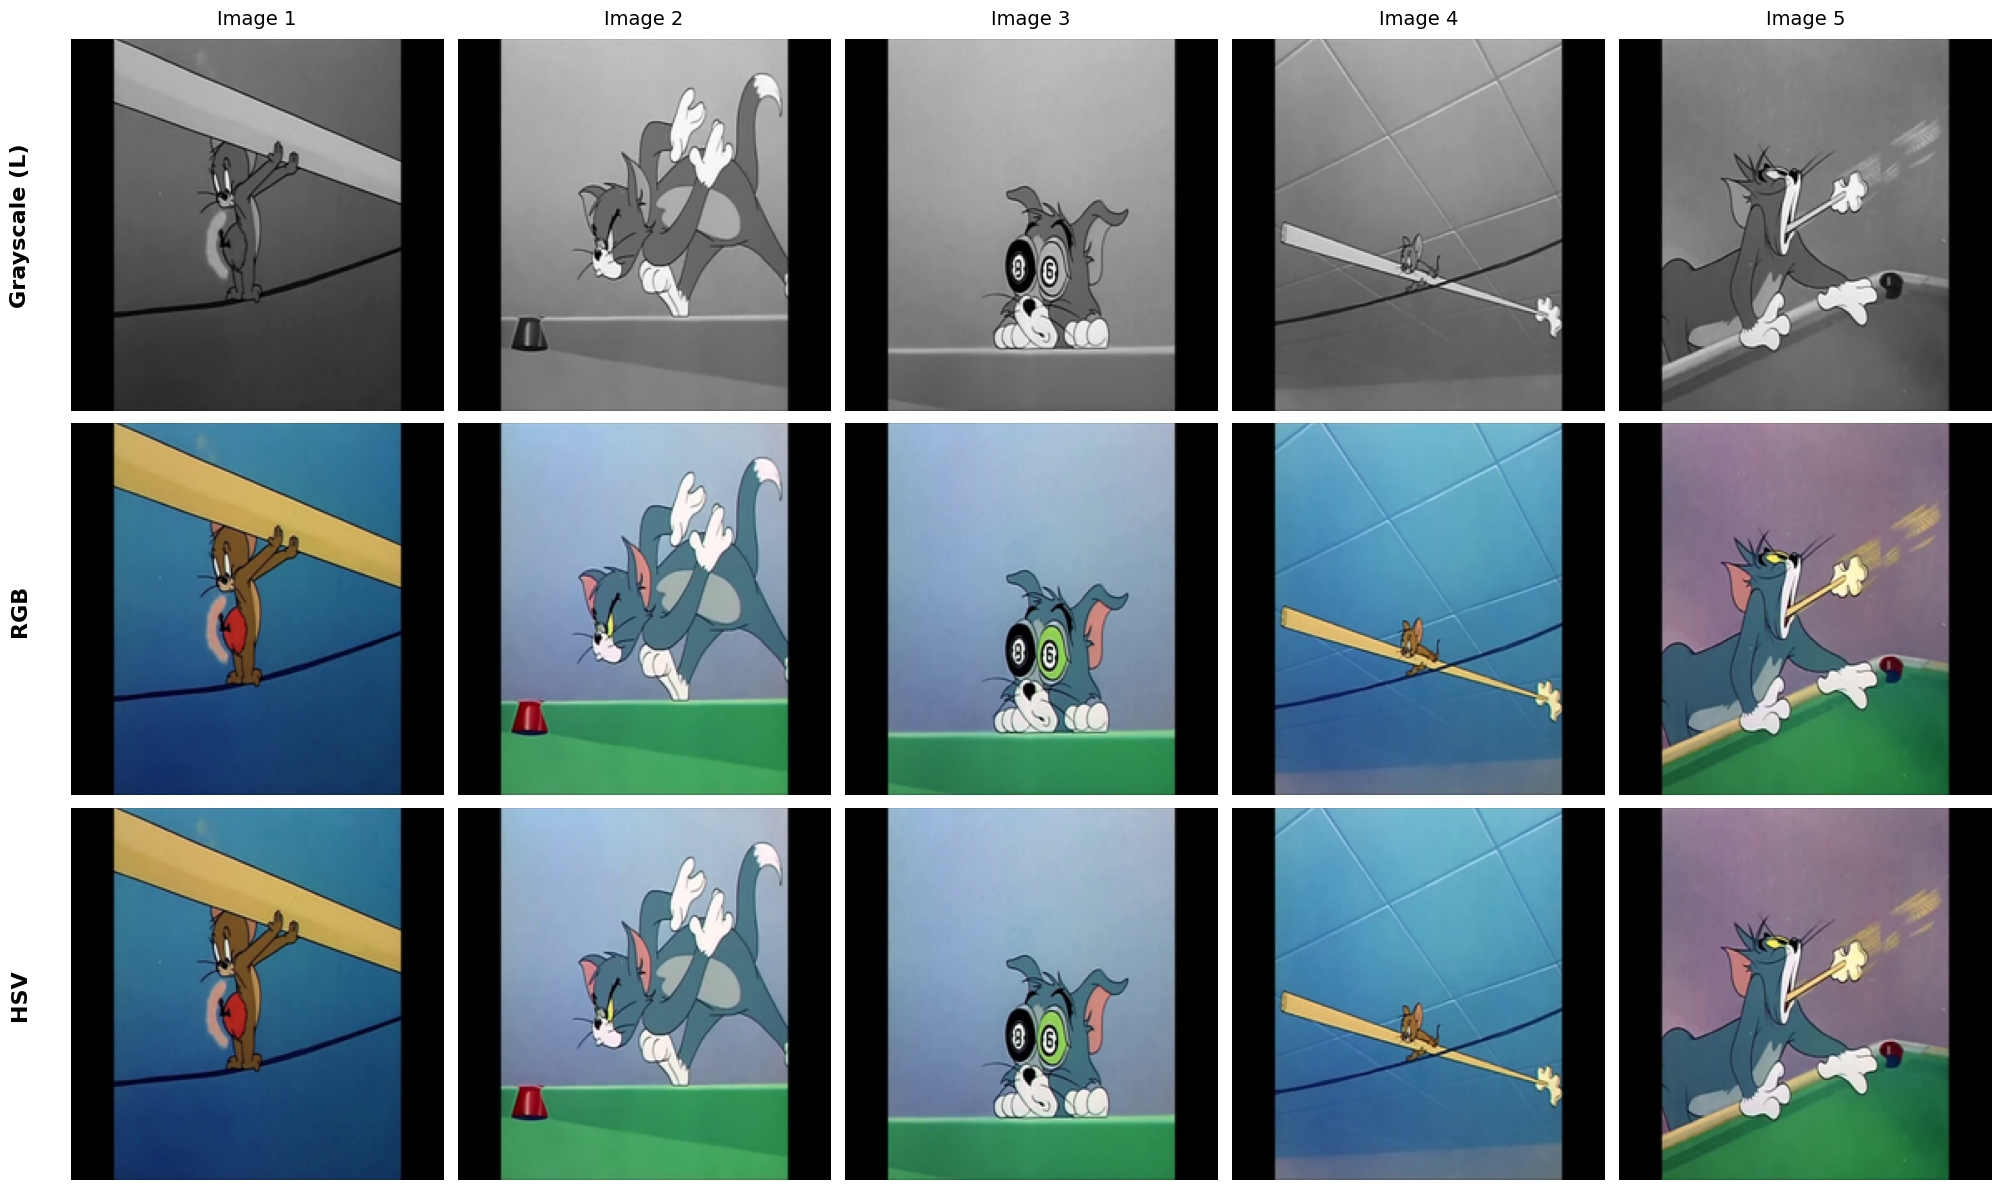

In [12]:
import matplotlib.pyplot as plt

# Create a grid of 3 rows (Grayscale, RGB, HSV) and 5 columns (for each image)
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

# Row titles for clarity
row_titles = ["Grayscale (L)", "RGB", "HSV"]

# Loop through each column (image 1 to 5)
for i in range(5):
    # --- Row 1: Grayscale ---
    # cmap="gray" ensures matplotlib displays the 1-channel 'L' image correctly
    axes[0, i].imshow(grayscale_images[i], cmap="gray")
    axes[0, i].axis("off")

    # --- Row 2: RGB ---
    axes[1, i].imshow(rgb_images[i])
    axes[1, i].axis("off")

    # --- Row 3: HSV ---
    axes[2, i].imshow(hsv_images[i])
    axes[2, i].axis("off")

    # Add image labels to the top row
    axes[0, i].set_title(f"Image {i+1}", fontsize=14, pad=10)

# Add titles to the far left of each row
for row_idx, title in enumerate(row_titles):
    axes[row_idx, 0].text(
        -25,
        112,
        title,
        fontsize=16,
        weight="bold",
        va="center",
        ha="right",
        rotation=90,
    )

plt.tight_layout()
plt.show()

In [13]:
import numpy as np

# 1. Normalize Grayscale Images
# Resulting shapes will be (224, 224)
grayscale_normalized = [np.array(img) / 255.0 for img in grayscale_images]

# 2. Normalize RGB Images
# Resulting shapes will be (224, 224, 3)
rgb_normalized = [np.array(img) / 255.0 for img in rgb_images]

# 3. Normalize HSV Images
# Resulting shapes will be (224, 224, 3)
hsv_normalized = [np.array(img) / 255.0 for img in hsv_images]

print("Normalization complete!")

# --- Verification Check ---
# Let's print the min and max pixel value of the first RGB image to verify
first_rgb_array = rgb_normalized[0]
print(f"\nVerification for Image 1 (RGB):")
print(f"Data Type: {first_rgb_array.dtype}")
print(f"Minimum pixel value: {first_rgb_array.min()}")
print(f"Maximum pixel value: {first_rgb_array.max()}")

Normalization complete!

Verification for Image 1 (RGB):
Data Type: float64
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [14]:
def preprocess_image(img_variable, target_size=(224, 224), color_mode="RGB"):
    """Preprocesses a PIL image variable by resizing, converting color,

    and normalizing pixel values to a 0-1 range.
    """
    # 1. Convert color mode ('RGB', 'L' for Grayscale, or 'HSV')
    img_processed = img_variable.convert(color_mode)

    # 2. Resize image using high-quality Lanczos downsampling
    img_processed = img_processed.resize(target_size, Image.Resampling.LANCZOS)

    # 3. Convert to NumPy array and normalize from 0-255 to 0-1
    img_array = np.array(img_processed) / 255.0

    return img_array

In [15]:
def augment_image(img_variable):
    """Applies random augmentations (Rotation, Flips, Zoom, Brightness)

    to a PIL image and returns the augmented image object.
    """
    # Make a copy so we don't accidentally modify the original variable
    img = img_variable.copy()

    # 1. Random Rotation (between -30 and 30 degrees)
    angle = random.uniform(-30, 30)
    img = img.rotate(angle, resample=Image.Resampling.BILINEAR)

    # 2. Random Flips
    if random.random() > 0.5:
        img = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)  # Horizontal Flip
    if random.random() > 0.5:
        img = img.transpose(Image.Transpose.FLIP_TOP_BOTTOM)  # Vertical Flip

    # 3. Random Brightness Adjustment (0.5 = dimmer, 1.5 = brighter)
    brightness_factor = random.uniform(0.6, 1.4)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(brightness_factor)

    # 4. Random Zoom / Crop
    if random.random() > 0.5:
        width, height = img.size
        # Define a random crop zoom factor (e.g., zoom into 85% to 95% of the image)
        zoom_factor = random.uniform(0.85, 0.95)
        crop_w, crop_h = int(width * zoom_factor), int(height * zoom_factor)

        # Calculate coordinates to crop from the center
        left = (width - crop_w) // 2
        top = (height - crop_h) // 2
        right = left + crop_w
        bottom = top + crop_h

        img = img.crop((left, top, right, bottom))
        img = img.resize((width, height), Image.Resampling.LANCZOS)

    return img

In [17]:
import random
from PIL import ImageEnhance, Image


def augment_image(img_variable):
    """Applies random augmentations (Rotation, Flips, Zoom, Brightness)

    to a PIL image and returns the augmented image object.
    """
    # Make a copy so we don't accidentally modify the original variable
    img = img_variable.copy()

    # 1. Random Rotation (between -30 and 30 degrees)
    angle = random.uniform(-30, 30)
    img = img.rotate(angle, resample=Image.Resampling.BILINEAR)

    # 2. Random Flips
    if random.random() > 0.5:
        img = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)  # Horizontal Flip
    if random.random() > 0.5:
        img = img.transpose(Image.Transpose.FLIP_TOP_BOTTOM)  # Vertical Flip

    # 3. Random Brightness Adjustment (0.6 = dimmer, 1.4 = brighter)
    brightness_factor = random.uniform(0.6, 1.4)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(brightness_factor)

    # 4. Random Zoom / Crop
    if random.random() > 0.5:
        width, height = img.size
        zoom_factor = random.uniform(0.85, 0.95)
        crop_w, crop_h = int(width * zoom_factor), int(height * zoom_factor)

        left = (width - crop_w) // 2
        top = (height - crop_h) // 2
        right = left + crop_w
        bottom = top + crop_h

        img = img.crop((left, top, right, bottom))
        img = img.resize((width, height), Image.Resampling.LANCZOS)

    return img

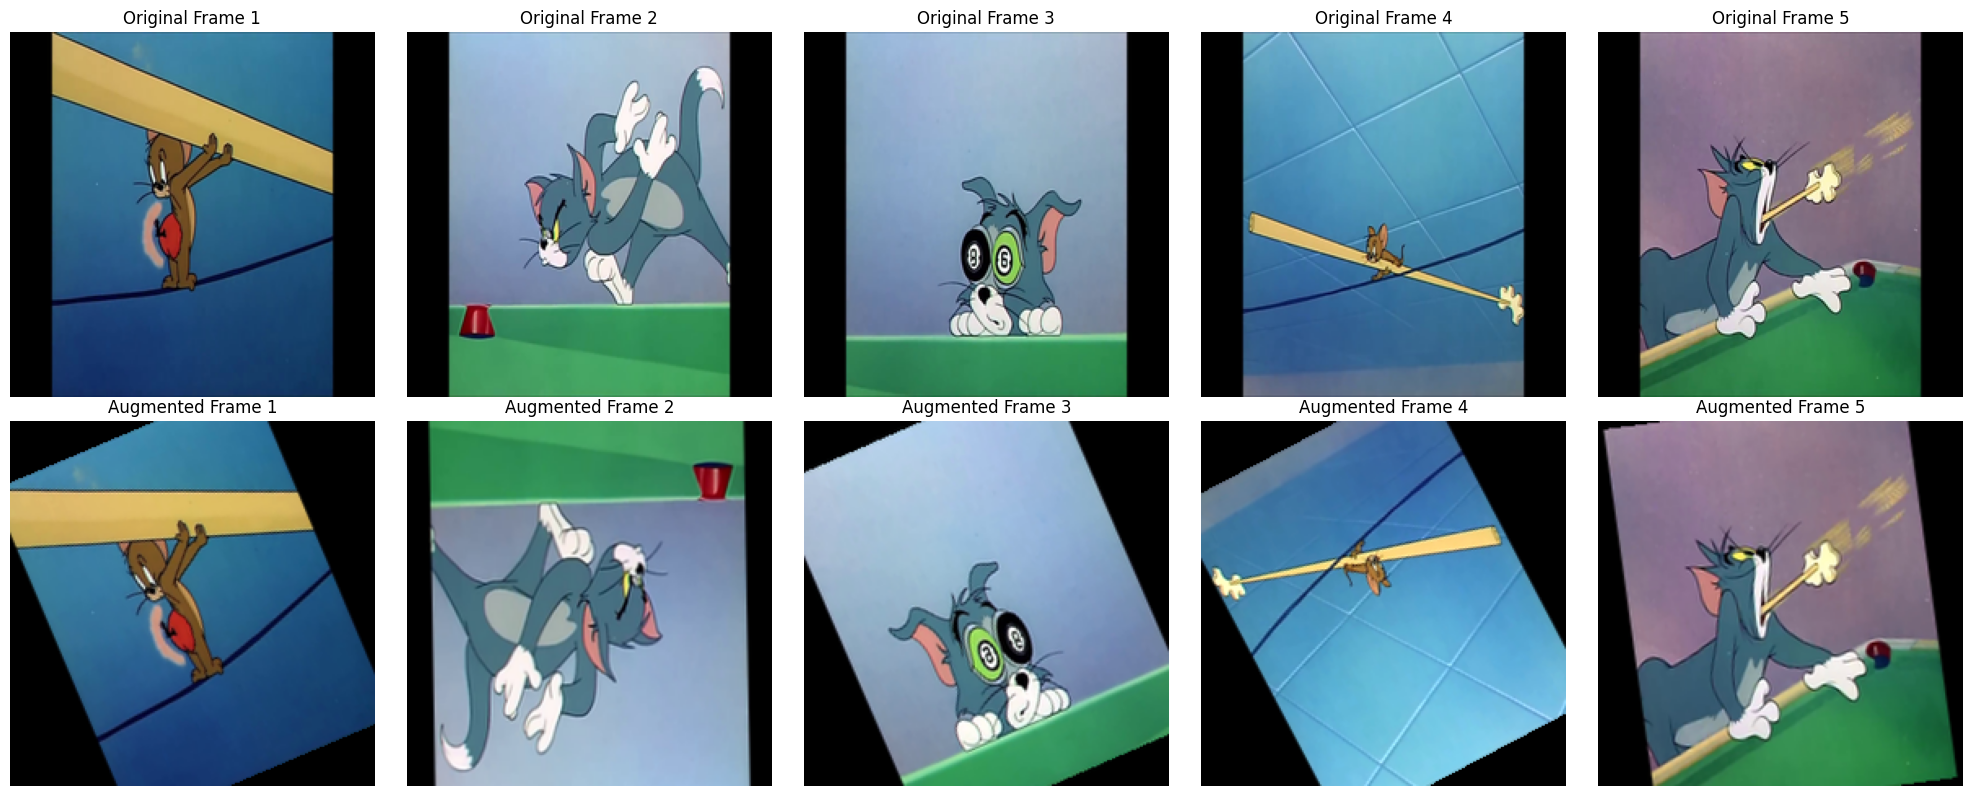

In [18]:
# Re-run your visualization code
original_images = [image, image2, image3, image4, image5]
augmented_images = [augment_image(img) for img in original_images]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i in range(5):
    axes[0, i].imshow(original_images[i].convert("RGB"))
    axes[0, i].set_title(f"Original Frame {i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(augmented_images[i].convert("RGB"))
    axes[1, i].set_title(f"Augmented Frame {i+1}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()